# 03. Giá bán, biên lợi nhuận và khuyến mãi

**Mục tiêu:** Tách biên lợi nhuận niêm yết (theo bảng giá) và biên thực tế (theo giao dịch), xem giá bán lệch giá niêm yết bao nhiêu và biên có biến động cùng các đợt khuyến mãi không.

**Bảng dữ liệu dùng:** `products`, `order_items`, `orders`, `promotions`

In [1]:
import sys
from pathlib import Path

# Tìm thư mục gốc repo (chứa src/ds317) để import thư viện chung
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "ds317").is_dir())
sys.path.insert(0, str(ROOT / "src"))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ds317 import load, load_many, order_lines, revenue_daily, weekly_category, REVENUE_LABELS
from ds317.viz import setup_style, nb_out, save_fig, source_note, key_numbers, MILLION, UNIT, NOTE_SALES, NOTE_TRAFFIC

%matplotlib inline
warnings.filterwarnings("ignore", category=FutureWarning)
setup_style()
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
FIG, TAB = nb_out("03_gia_bien_loi_nhuan_khuyen_mai")
print("Ảnh lưu tại:", FIG.relative_to(ROOT))

Ảnh lưu tại: outputs\eda\03_gia_bien_loi_nhuan_khuyen_mai


**Các loại biên lợi nhuận dùng trong notebook:**

| Tên | Công thức | Nguồn |
|---|---|---|
| Biên niêm yết (TB SKU) | trung bình của (`price − cogs`) / `price` trên các SKU | `products` |
| Biên niêm yết (theo lượng bán) | SUM(`quantity × (price − cogs)`) / SUM(`quantity × price`) | `products` × `order_items` |
| Biên thực tế gộp | SUM(`quantity × unit_price` − `cogs_line`) / SUM(`quantity × unit_price`) | `order_items`, gồm đơn huỷ (khớp `sales`) |
| Biên thực tế net | SUM(`net` − `cogs_line`) / SUM(`net`) | `order_items`, bỏ đơn huỷ, sau chiết khấu |

In [2]:
products = load("products")
promos = load("promotions")
lines = order_lines()
lines["Year"] = lines.order_date.dt.year
lines["list_rev"] = lines.quantity * lines.price
products["bien_niem_yet_pct"] = (products.price - products.cogs) / products.price * 100

## Biên lợi nhuận niêm yết và biên thực tế khác nhau bao nhiêu, theo danh mục?

,bien_niem_yet_tb_sku,bien_niem_yet_theo_luong_ban,bien_thuc_te_gop,bien_thuc_te_net,gia_ban_tren_niem_yet_pct
Casual,28.48,16.15,11.75,7.73,95.00
GenZ,24.08,23.07,19.13,15.41,95.12
Outdoor,26.94,21.71,16.37,11.39,93.61
Streetwear,26.39,19.67,13.24,9.28,92.59
Tất cả,26.59,19.95,13.80,9.68,92.86


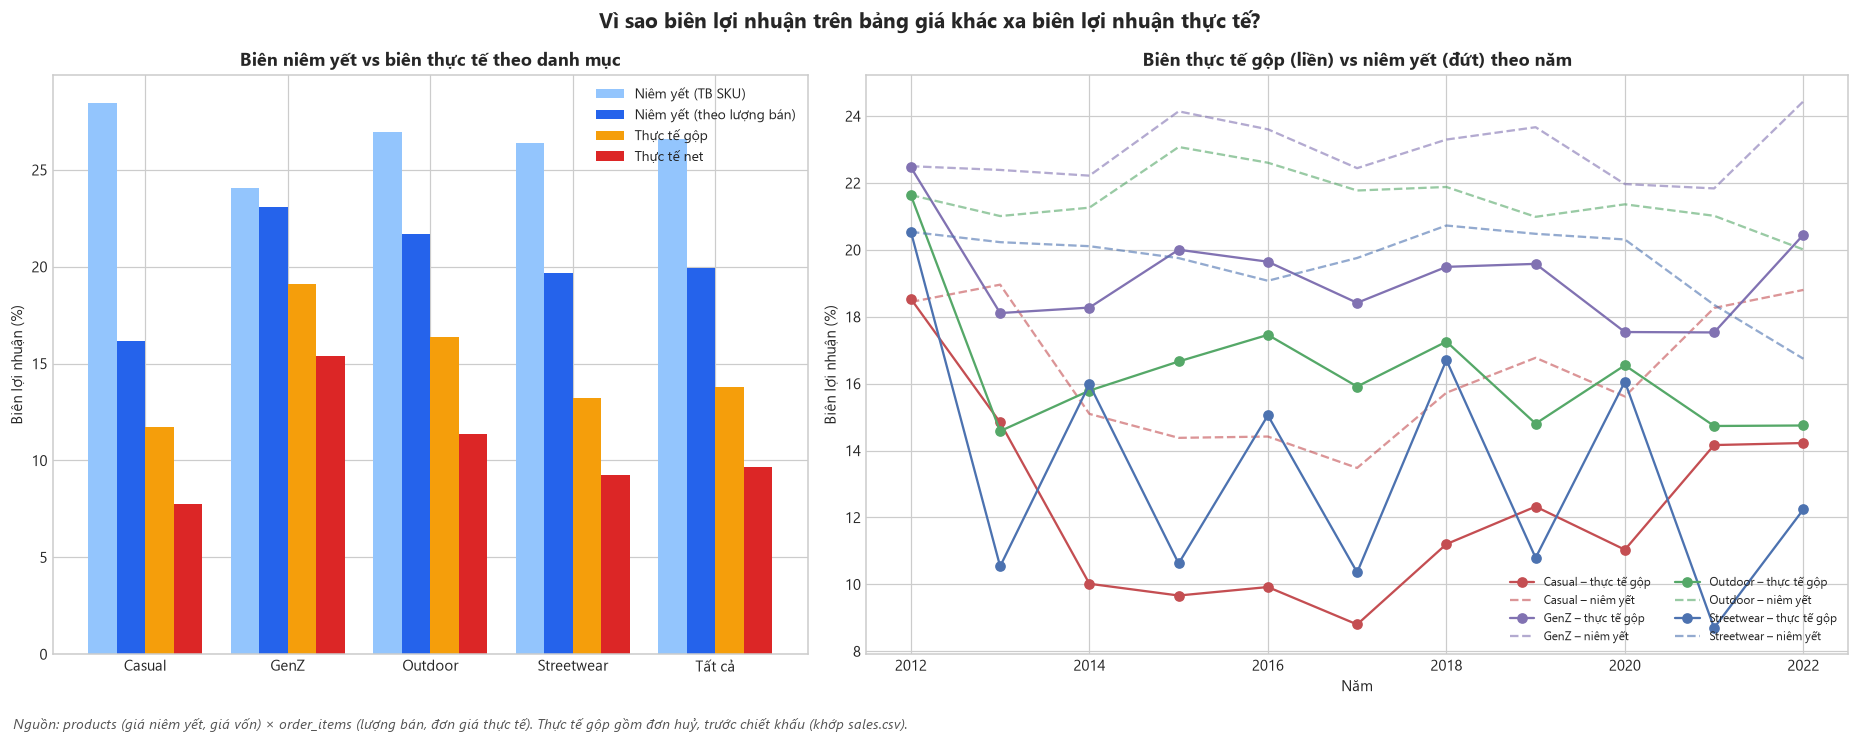

  đã lưu 03a_bien_niem_yet_vs_thuc_te.png


In [3]:
def margins(df, by):
    g = df.groupby(by)
    nc = df[~df.is_cancelled].groupby(by)
    return pd.DataFrame({
        "bien_niem_yet_theo_luong_ban": (g.list_rev.sum() - g.cogs_line.sum()) / g.list_rev.sum() * 100,
        "bien_thuc_te_gop": (g.gross.sum() - g.cogs_line.sum()) / g.gross.sum() * 100,
        "bien_thuc_te_net": (nc.net.sum() - nc.cogs_line.sum()) / nc.net.sum() * 100,
        "gia_ban_tren_niem_yet_pct": g.gross.sum() / g.list_rev.sum() * 100,
    })

by_cat = margins(lines, "category")
by_cat.insert(0, "bien_niem_yet_tb_sku", products.groupby("category").bien_niem_yet_pct.mean())
all_row = margins(lines.assign(all="Tất cả"), "all")
all_row.insert(0, "bien_niem_yet_tb_sku", products.bien_niem_yet_pct.mean())
by_cat = pd.concat([by_cat, all_row])
by_cat_year = margins(lines, ["category", "Year"])
by_cat.to_csv(TAB / "bien_theo_danh_muc.csv", encoding="utf-8-sig")
by_cat_year.to_csv(TAB / "bien_theo_danh_muc_nam.csv", encoding="utf-8-sig")
display(by_cat.round(2))

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5), gridspec_kw={"width_ratios": [1, 1.3]})
labels = {"bien_niem_yet_tb_sku": "Niêm yết (TB SKU)", "bien_niem_yet_theo_luong_ban": "Niêm yết (theo lượng bán)",
          "bien_thuc_te_gop": "Thực tế gộp", "bien_thuc_te_net": "Thực tế net"}
by_cat[list(labels)].rename(columns=labels).plot(kind="bar", ax=axes[0], color=["#93c5fd", "#2563eb", "#f59e0b", "#dc2626"], width=0.8)
axes[0].set_title("Biên niêm yết vs biên thực tế theo danh mục", fontweight="bold")
axes[0].set_ylabel("Biên lợi nhuận (%)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(fontsize=9)
COLORS = {"Casual": "#C44E52", "GenZ": "#8172B2", "Outdoor": "#55A868", "Streetwear": "#4C72B0"}
for cat, g in by_cat_year.reset_index().groupby("category"):
    axes[1].plot(g.Year, g.bien_thuc_te_gop, marker="o", color=COLORS[cat], label=f"{cat} – thực tế gộp")
    axes[1].plot(g.Year, g.bien_niem_yet_theo_luong_ban, ls="--", color=COLORS[cat], alpha=0.6, label=f"{cat} – niêm yết")
axes[1].set_title("Biên thực tế gộp (liền) vs niêm yết (đứt) theo năm", fontweight="bold")
axes[1].set_ylabel("Biên lợi nhuận (%)")
axes[1].set_xlabel("Năm")
axes[1].legend(fontsize=8, ncol=2)
fig.suptitle("Vì sao biên lợi nhuận trên bảng giá khác xa biên lợi nhuận thực tế?", fontsize=14, fontweight="bold")
fig.tight_layout()
source_note(fig, "Nguồn: products (giá niêm yết, giá vốn) × order_items (lượng bán, đơn giá thực tế). Thực tế gộp gồm đơn huỷ, trước chiết khấu (khớp sales.csv).")
save_fig(fig, FIG / "03a_bien_niem_yet_vs_thuc_te.png")

In [4]:
a = by_cat.loc["Tất cả"]
key_numbers({
    "Biên niêm yết TB SKU / theo lượng bán": f"{a.bien_niem_yet_tb_sku:.2f}% / {a.bien_niem_yet_theo_luong_ban:.2f}%",
    "Biên thực tế gộp / net": f"{a.bien_thuc_te_gop:.2f}% / {a.bien_thuc_te_net:.2f}%",
    "Đơn giá thực tế / giá niêm yết (toàn kỳ)": f"{a.gia_ban_tren_niem_yet_pct:.2f}%",
    "Chênh niêm yết (theo lượng bán) − thực tế gộp": f"{a.bien_niem_yet_theo_luong_ban - a.bien_thuc_te_gop:.2f} điểm %",
    "Năm có biên thực tế gộp thấp nhất (Streetwear)": f"{by_cat_year.loc['Streetwear'].bien_thuc_te_gop.idxmin()} ({by_cat_year.loc['Streetwear'].bien_thuc_te_gop.min():.2f}%)",
})

Số liệu chính:
  - Biên niêm yết TB SKU / theo lượng bán: 26.59% / 19.95%
  - Biên thực tế gộp / net: 13.80% / 9.68%
  - Đơn giá thực tế / giá niêm yết (toàn kỳ): 92.86%
  - Chênh niêm yết (theo lượng bán) − thực tế gộp: 6.15 điểm %
  - Năm có biên thực tế gộp thấp nhất (Streetwear): 2021 (8.70%)


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …

## Đơn giá bán thực tế lệch giá niêm yết bao nhiêu?

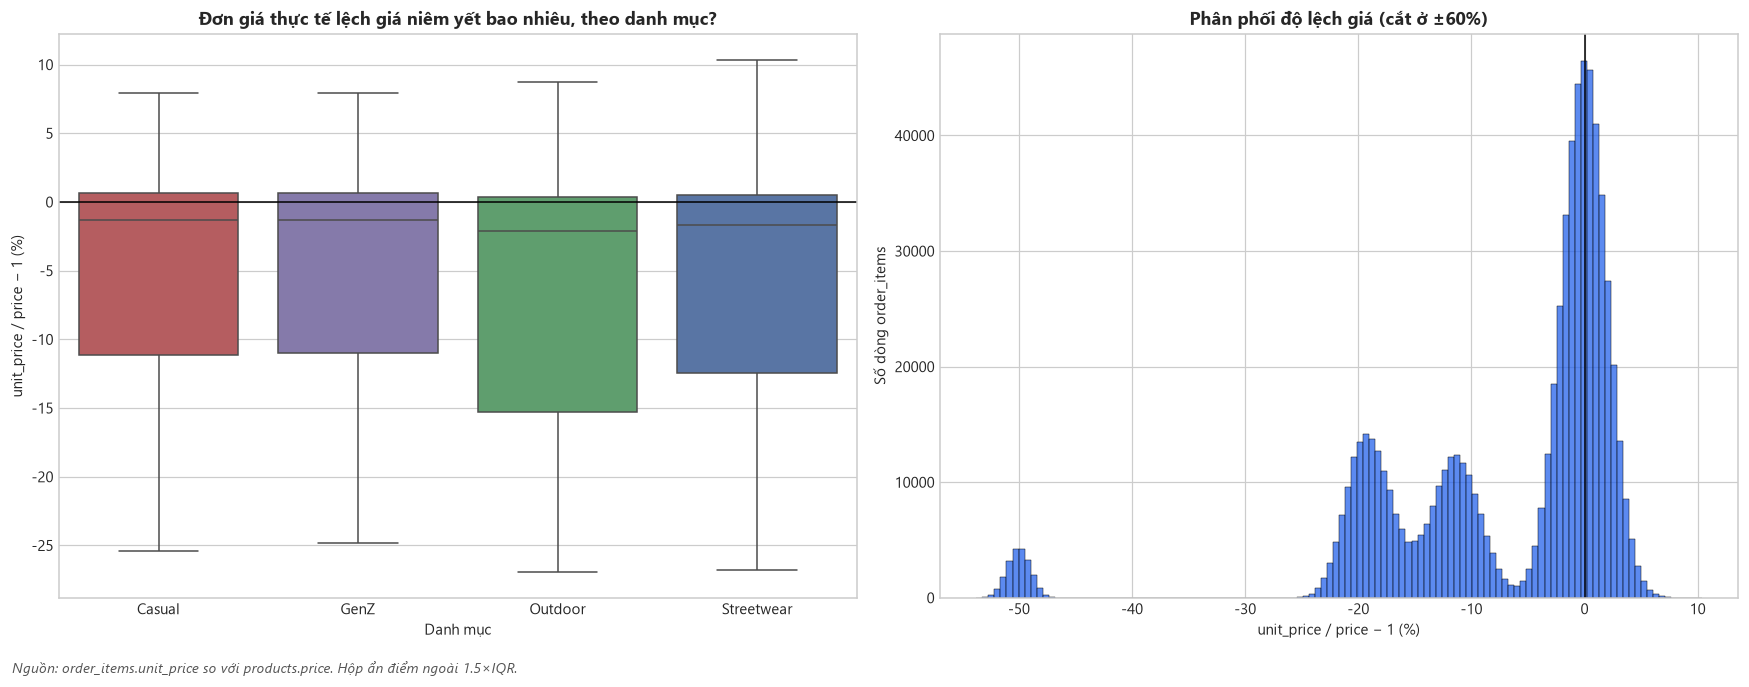

  đã lưu 03b_lech_gia_ban_vs_niem_yet.png


,count,mean,std,min,5%,25%,50%,75%,95%,max
category,,,,,,,,,,
Casual,23991.0,-4.97,7.62,-25.40,-19.85,-11.14,-1.29,0.64,2.86,7.96
GenZ,37159.0,-4.92,7.64,-24.84,-19.78,-11.03,-1.32,0.65,2.90,7.96
Outdoor,259986.0,-6.76,8.60,-26.95,-20.99,-15.30,-2.14,0.35,2.73,8.74
Streetwear,393533.0,-7.38,12.49,-53.77,-48.45,-12.42,-1.69,0.51,2.80,10.36


In [5]:
lines["lech_gia_pct"] = (lines.unit_price / lines.price - 1) * 100
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=lines, x="category", y="lech_gia_pct", ax=axes[0], palette=COLORS, showfliers=False,
            order=sorted(COLORS))
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title("Đơn giá thực tế lệch giá niêm yết bao nhiêu, theo danh mục?", fontweight="bold")
axes[0].set_ylabel("unit_price / price − 1 (%)")
axes[0].set_xlabel("Danh mục")
sns.histplot(lines.lech_gia_pct.clip(-60, 60), bins=120, ax=axes[1], color="#2563eb")
axes[1].axvline(0, color="black", lw=1)
axes[1].set_title("Phân phối độ lệch giá (cắt ở ±60%)", fontweight="bold")
axes[1].set_xlabel("unit_price / price − 1 (%)")
axes[1].set_ylabel("Số dòng order_items")
fig.tight_layout()
source_note(fig, "Nguồn: order_items.unit_price so với products.price. Hộp ẩn điểm ngoài 1.5×IQR.")
save_fig(fig, FIG / "03b_lech_gia_ban_vs_niem_yet.png")
dev = lines.groupby("category").lech_gia_pct.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
dev.to_csv(TAB / "lech_gia_theo_danh_muc.csv", encoding="utf-8-sig")
dev.round(2)

In [6]:
key_numbers({
    "% dòng có unit_price ≠ price (±0.01)": f"{((lines.unit_price - lines.price).abs() > 0.01).mean() * 100:.2f}%",
    "% dòng bán thấp hơn / cao hơn niêm yết": f"{(lines.lech_gia_pct < 0).mean() * 100:.1f}% / {(lines.lech_gia_pct > 0).mean() * 100:.1f}%",
    "Trung vị độ lệch": f"{lines.lech_gia_pct.median():.2f}%",
    "% dòng bán dưới giá vốn (unit_price < cogs)": f"{(lines.unit_price < lines.cogs).mean() * 100:.2f}%",
})

Số liệu chính:
  - % dòng có unit_price ≠ price (±0.01): 99.99%
  - % dòng bán thấp hơn / cao hơn niêm yết: 69.3% / 30.7%
  - Trung vị độ lệch: -1.79%
  - % dòng bán dưới giá vốn (unit_price < cogs): 18.62%


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …

## Các đợt sụt biên lợi nhuận có trùng thời gian khuyến mãi không?

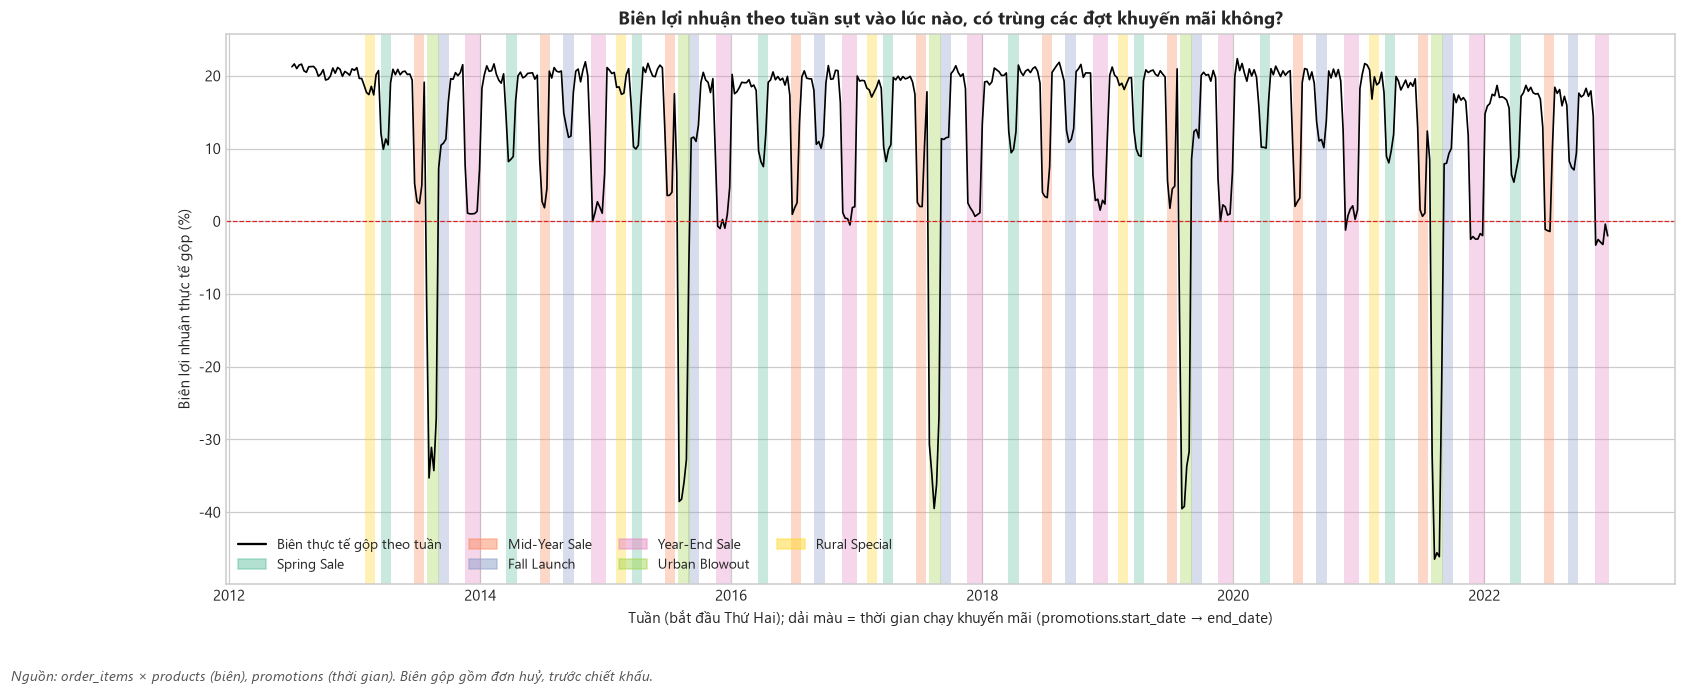

  đã lưu 03c_khuyen_mai_vs_bien_loi_nhuan.png


,week_start,bien_thuc_te_gop,khuyen_mai_dang_chay
0,2021-08-09,-46.46,Urban Blowout 2021
1,2021-08-23,-46.12,Urban Blowout 2021
2,2021-08-16,-45.58,Urban Blowout 2021
3,2019-08-05,-39.52,Urban Blowout 2019
4,2017-08-14,-39.50,Urban Blowout 2017
5,2019-08-12,-39.20,Urban Blowout 2019
6,2015-08-03,-38.53,Urban Blowout 2015
7,2015-08-10,-38.20,Urban Blowout 2015
8,2017-08-21,-36.19,Urban Blowout 2017
9,2015-08-17,-35.90,Urban Blowout 2015


In [7]:
wk = lines.assign(week_start=lines.order_date.dt.to_period("W-SUN").dt.start_time).groupby("week_start")
weekly_margin = ((wk.gross.sum() - wk.cogs_line.sum()) / wk.gross.sum() * 100).rename("bien_thuc_te_gop")
THEMES = ["Spring Sale", "Mid-Year Sale", "Fall Launch", "Year-End Sale", "Urban Blowout", "Rural Special"]
promos["theme"] = promos.promo_name.str.replace(r"\s\d{4}$", "", regex=True)
pal = dict(zip(THEMES, sns.color_palette("Set2", len(THEMES))))

fig, ax = plt.subplots(figsize=(17, 6.5))
for r in promos.itertuples():
    ax.axvspan(r.start_date, r.end_date, color=pal.get(r.theme, "#cccccc"), alpha=0.35, lw=0)
ax.plot(weekly_margin.index, weekly_margin.values, color="black", lw=1.1, label="Biên thực tế gộp theo tuần")
ax.axhline(0, color="#dc2626", lw=0.8, ls="--")
from matplotlib.patches import Patch
ax.legend(handles=[plt.Line2D([], [], color="black", label="Biên thực tế gộp theo tuần")]
          + [Patch(color=pal[t], alpha=0.5, label=t) for t in THEMES], loc="lower left", ncol=4, fontsize=9)
ax.set_title("Biên lợi nhuận theo tuần sụt vào lúc nào, có trùng các đợt khuyến mãi không?", fontweight="bold")
ax.set_ylabel("Biên lợi nhuận thực tế gộp (%)")
ax.set_xlabel("Tuần (bắt đầu Thứ Hai); dải màu = thời gian chạy khuyến mãi (promotions.start_date → end_date)")
source_note(fig, "Nguồn: order_items × products (biên), promotions (thời gian). Biên gộp gồm đơn huỷ, trước chiết khấu.")
save_fig(fig, FIG / "03c_khuyen_mai_vs_bien_loi_nhuan.png")

def active(week):
    end = week + pd.Timedelta(days=6)
    hit = promos[(promos.start_date <= end) & (promos.end_date >= week)]
    return ", ".join(hit.promo_name) or "(không có)"
low = weekly_margin.nsmallest(12).rename_axis("week_start").reset_index()
low["khuyen_mai_dang_chay"] = low.week_start.map(active)
low.to_csv(TAB / "tuan_bien_thap_nhat.csv", index=False, encoding="utf-8-sig")
low.round({"bien_thuc_te_gop": 2})

In [8]:
in_promo = weekly_margin.index.map(lambda w: active(w) != "(không có)")
key_numbers({
    "Số tuần biên âm": f"{(weekly_margin < 0).sum()} / {len(weekly_margin)}",
    "Biên TB tuần có / không có khuyến mãi chạy": f"{weekly_margin[in_promo].mean():.2f}% / {weekly_margin[~in_promo].mean():.2f}%",
    "Trong 12 tuần biên thấp nhất, số tuần có khuyến mãi chạy": f"{(low.khuyen_mai_dang_chay != '(không có)').sum()} / 12",
    "Tháng của 12 tuần biên thấp nhất": ", ".join(sorted({f"{d.year}-{d.month:02d}" for d in low.week_start})),
})

Số liệu chính:
  - Số tuần biên âm: 46 / 548
  - Biên TB tuần có / không có khuyến mãi chạy: 5.59% / 19.80%
  - Trong 12 tuần biên thấp nhất, số tuần có khuyến mãi chạy: 12 / 12
  - Tháng của 12 tuần biên thấp nhất: 2013-08, 2015-08, 2017-08, 2019-08, 2021-08


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …

## Mỗi danh mục có bao nhiêu SKU ở từng phân khúc?

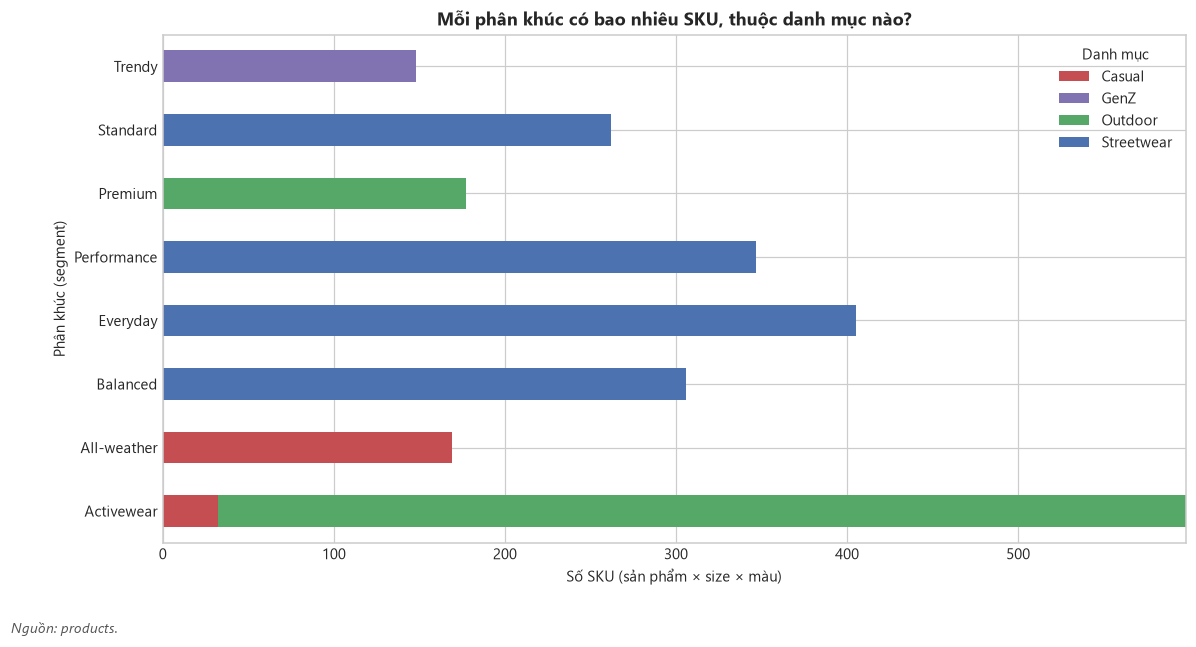

  đã lưu 03d_so_sku_phan_khuc.png


category,Casual,GenZ,Outdoor,Streetwear
segment,,,,
Activewear,32,0,566,0
All-weather,169,0,0,0
Balanced,0,0,0,306
Everyday,0,0,0,405
Performance,0,0,0,347
Premium,0,0,177,0
Standard,0,0,0,262
Trendy,0,148,0,0


In [9]:
sku = pd.crosstab(products.segment, products.category)
fig, ax = plt.subplots(figsize=(12, 6))
sku.plot(kind="barh", stacked=True, ax=ax, color=[COLORS[c] for c in sku.columns])
ax.set_title("Mỗi phân khúc có bao nhiêu SKU, thuộc danh mục nào?", fontweight="bold")
ax.set_xlabel("Số SKU (sản phẩm × size × màu)")
ax.set_ylabel("Phân khúc (segment)")
ax.legend(title="Danh mục")
source_note(fig, "Nguồn: products.")
save_fig(fig, FIG / "03d_so_sku_phan_khuc.png")
sku.to_csv(TAB / "so_sku_phan_khuc.csv", encoding="utf-8-sig")
sku

In [10]:
key_numbers({
    "Tổng số SKU": f"{len(products):,}",
    "SKU theo danh mục": ", ".join(f"{c} {n}" for c, n in products.category.value_counts().items()),
    "Số phân khúc / phân khúc chỉ thuộc 1 danh mục": f"{products.segment.nunique()} / {(sku.gt(0).sum(axis=1) == 1).sum()}",
    "SKU có giao dịch trong order_items": f"{lines.product_id.nunique():,} / {len(products):,}",
})

Số liệu chính:
  - Tổng số SKU: 2,412
  - SKU theo danh mục: Streetwear 1320, Outdoor 743, Casual 201, GenZ 148
  - Số phân khúc / phân khúc chỉ thuộc 1 danh mục: 8 / 7
  - SKU có giao dịch trong order_items: 1,598 / 2,412


> **Đọc chart (nhóm điền):**
> 1. Kết luận 1 câu có số: …
> 2. Số kiểm tra lại từ data: …
> 3. Điều lạ / chưa giải thích được: …
> 4. Ảnh hưởng đến tiền xử lý hoặc mô hình: …